In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
retail_lgd_df = pd.read_csv('output/recovery.csv')
retail_lgd_df['Quarter_dt'] = pd.to_datetime(retail_lgd_df['Quarter_dt'])
retail_lgd_df.set_index('Quarter_dt', inplace=True)
retail_lgd_df.index = retail_lgd_df.index.to_period('Q')
retail_lgd_df

,Retail_LGD_pc
Quarter_dt,
2019Q2,0.891720
2019Q3,0.882906
2019Q4,0.883284
2020Q1,0.878344
2020Q2,0.853256
2020Q3,0.816910
2020Q4,0.782561
2021Q1,0.803247
2021Q2,0.749945


In [4]:
macro_path = './output/ccar_macro_data_quarterly.csv'
df_macro = pd.read_csv(macro_path)
df_macro['DATE'] = pd.to_datetime(df_macro['DATE'])
df_macro.set_index('DATE', inplace=True)
df_macro.index = df_macro.index.to_period('Q')

df_macro.columns

Index(['Unemployment_Rate', 'Real_GDP', 'BBB_Spread', 'VIX_Volatility_Index',
       '10Y_Treasury_Yield', '3M_Treasury_Rate', 'Prime_Rate', 'CPI_Inflation',
       'Real_Disposable_Income', 'Nominal_GDP', 'Corporate_Profits',
       'House_Price_Index', 'Stock_Market_Index', 'NFCI_Financial_Conditions',
       'STLFSI_Financial_Stress', 'HY_Spread', 'AAA_Spread', 'AA_Spread',
       'Industrial_Production', 'Capacity_Utilization', 'Real_GDP_Growth',
       'Nominal_GDP_Growth', 'Corp_Profits_YoY', 'HPI_YoY',
       'Stock_Market_Return', 'CPI_YoY', 'INDPRO_YoY', 'INDPRO_Growth',
       'TCU_Change', 'Term_Spread_10Y_3M', 'RDI_YoY', 'RDI_Growth',
       '10Y_Change', '3M_Change', 'Prime_Change', 'BBB_Change', 'HY_Change'],
      dtype='object')

In [5]:
df_model = retail_lgd_df[['Retail_LGD_pc']].join(df_macro, how='inner')
#df_model = df_model.drop(['VIX_Volatility_Index', 'BBB_Spread','Prime_Rate','Nominal_GDP','Corporate_Profits','Stock_Market_Index','Nominal_GDP_Growth','Corp_Profits_YoY','House_Price_Index','Stock_Market_Return','Real_GDP'], axis=1)

df_model = df_model.dropna()
print(df_model)

        Retail_LGD_pc  Unemployment_Rate   Real_GDP  BBB_Spread  \
2019Q2       0.891720           3.633333  20602.275    1.588769   
2019Q3       0.882906           3.600000  20843.322    1.565075   
2019Q4       0.883284           3.600000  20985.448    1.446615   
2020Q1       0.878344           3.833333  20709.212    1.981692   
2020Q2       0.853256          13.000000  19077.992    2.713846   
2020Q3       0.816910           8.800000  20558.879    1.823485   
2020Q4       0.782561           6.766667  20791.917    1.537879   
2021Q1       0.803247           6.233333  21082.134    1.241846   
2021Q2       0.749945           5.933333  21440.929    1.137812   
2021Q3       0.656657           5.066667  21617.828    1.125522   
2021Q4       0.678888           4.166667  21988.737    1.162879   
2022Q1       0.693854           3.866667  21932.710    1.450312   
2022Q2       0.730450           3.633333  21967.045    1.724462   
2022Q3       0.741269           3.533333  22125.625    1.89164

In [6]:
# --- Step 1: Define the 15 Core Relevant Variables ---

core_vars = [
    'Unemployment_Rate', 'Real_GDP', '3M_Treasury_Rate', '10Y_Treasury_Yield',
    'Prime_Rate', 'CPI_Inflation', 'Real_Disposable_Income', 'HPI_YoY',
    'Stock_Market_Index', 'VIX_Volatility_Index', 'HY_Spread', 
    'STLFSI_Financial_Stress', 'BBB_Spread', 'Real_GDP_Growth', 'RDI_Growth'
]

# --- Step 2: Create "Change" and "Growth" Versions ---
df_transformed = df_model[['Retail_LGD_pc']].copy()

# A. Percentage Growth Variables (Stock Market, GDP, Income)
df_transformed['Stock_Market_Return'] = df_model['Stock_Market_Index'].pct_change()
df_transformed['Real_GDP_QoQ'] = df_model['Real_GDP'].pct_change()
df_transformed['RDI_QoQ'] = df_model['Real_Disposable_Income'].pct_change()
df_transformed['CPI_QoQ_Inflation'] = df_model['CPI_Inflation'].pct_change()

# B. Absolute Changes in Rates (Prime, 10Y, 3M)
df_transformed['Prime_Rate_Chg'] = df_model['Prime_Rate'].diff()
df_transformed['10Y_Yield_Chg'] = df_model['10Y_Treasury_Yield'].diff()
df_transformed['3M_Rate_Chg'] = df_model['3M_Treasury_Rate'].diff()

# C. Keep "Levels" for Stress Indicators
df_transformed['Unemployment_Rate'] = df_model['Unemployment_Rate']
df_transformed['VIX'] = df_model['VIX_Volatility_Index']
df_transformed['HY_Spread'] = df_model['HY_Spread']
df_transformed['BBB_Spread'] = df_model['BBB_Spread']
df_transformed['Financial_Stress_Index'] = df_model['STLFSI_Financial_Stress']
df_transformed['HPI_YoY'] = df_model['HPI_YoY']

# --- Step 3: Generate Lags (1 to 4 Quarters) ---
# This turns 15 variables into a pool of 75 potential features
features_to_lag = [col for col in df_transformed.columns if col != 'Retail_LGD_pc']

for col in features_to_lag:
    for lag in [1, 2, 3, 4]:
        df_transformed[f'{col}_Lag{lag}'] = df_transformed[col].shift(lag)

# Drop rows with NaNs created by diff/pct_change/lags
df_transformed = df_transformed.dropna()

# --- Step 4: Final Feature Pool ---
X_pool = df_transformed.drop('Retail_LGD_pc', axis=1)
y = df_transformed['Retail_LGD_pc']

print(f"Transformation complete. Your X_pool now has {X_pool.shape[1]} features.")
print(X_pool.columns[:15]) # Show the main transformed columns

Transformation complete. Your X_pool now has 65 features.
Index(['Stock_Market_Return', 'Real_GDP_QoQ', 'RDI_QoQ', 'CPI_QoQ_Inflation',
       'Prime_Rate_Chg', '10Y_Yield_Chg', '3M_Rate_Chg', 'Unemployment_Rate',
       'VIX', 'HY_Spread', 'BBB_Spread', 'Financial_Stress_Index', 'HPI_YoY',
       'Stock_Market_Return_Lag1', 'Stock_Market_Return_Lag2'],
      dtype='object')


In [7]:
X_pool



,Stock_Market_Return,Real_GDP_QoQ,RDI_QoQ,CPI_QoQ_Inflation,Prime_Rate_Chg,10Y_Yield_Chg,3M_Rate_Chg,Unemployment_Rate,VIX,HY_Spread,...,BBB_Spread_Lag3,BBB_Spread_Lag4,Financial_Stress_Index_Lag1,Financial_Stress_Index_Lag2,Financial_Stress_Index_Lag3,Financial_Stress_Index_Lag4,HPI_YoY_Lag1,HPI_YoY_Lag2,HPI_YoY_Lag3,HPI_YoY_Lag4
2020Q3,0.201942,0.077623,-0.034440,0.011431,0.000000,-0.036994,-0.030000,8.800000,25.808906,5.369848,...,1.446615,1.565075,1.146923,1.025308,-0.097746,-0.181085,0.044480,0.042972,0.034356,0.031259
2020Q4,0.094045,0.011335,-0.020356,0.007214,0.000000,0.213891,-0.020000,6.766667,25.621719,4.548636,...,1.981692,1.446615,-0.032031,1.146923,1.025308,-0.097746,0.059083,0.044480,0.042972,0.034356
2021Q1,0.116859,0.013958,0.122752,0.010152,0.000000,0.471386,-0.043333,6.233333,23.202459,3.615846,...,2.713846,1.981692,-0.210546,-0.032031,1.146923,1.025308,0.094545,0.059083,0.044480,0.042972
2021Q2,0.037223,0.017019,-0.076340,0.018230,0.000000,0.254880,-0.023333,5.933333,18.000000,3.257500,...,1.823485,2.713846,-0.517100,-0.210546,-0.032031,1.146923,0.123366,0.094545,0.059083,0.044480
2021Q3,0.071599,0.008251,-0.011455,0.015935,0.000000,-0.265937,0.020000,5.066667,18.287344,3.203433,...,1.537879,1.823485,-0.775200,-0.517100,-0.210546,-0.032031,0.169173,0.123366,0.094545,0.059083
2021Q4,0.037117,0.017158,-0.011151,0.021778,0.000000,0.208543,0.006667,4.166667,19.275156,3.214394,...,1.241846,1.537879,-0.714162,-0.775200,-0.517100,-0.210546,0.198194,0.169173,0.123366,0.094545
2022Q1,-0.090325,-0.002548,-0.029778,0.022005,0.044355,0.417742,0.253333,3.866667,25.372903,3.559063,...,1.137812,1.241846,-0.647864,-0.714162,-0.775200,-0.517100,0.189085,0.198194,0.169173,0.123366
2022Q2,-0.128950,0.001565,-0.005140,0.023515,0.634217,0.981452,0.770000,3.633333,27.398438,4.347231,...,1.125522,1.137812,-0.306233,-0.647864,-0.714162,-0.775200,0.200315,0.189085,0.198194,0.169173
2022Q3,-0.024942,0.007219,0.015947,0.013195,1.444505,0.168513,1.586667,3.533333,24.792727,4.931493,...,1.162879,1.125522,0.016831,-0.306233,-0.647864,-0.714162,0.195191,0.200315,0.189085,0.198194
2022Q4,-0.085753,0.006902,0.010104,0.010454,1.446595,0.725628,1.376667,3.566667,25.002656,4.748923,...,1.450312,1.162879,-0.076329,0.016831,-0.306233,-0.647864,0.130571,0.195191,0.200315,0.189085


In [8]:
y_values = y

# Clip values slightly away from 0 and 1 to avoid infinity in log
eps = 0.001
y_clipped = np.clip(y_values, eps, 1 - eps)
y_logit = np.log(y_clipped / (1 - y_clipped))


y_logit_series = pd.Series(y_logit, index=y.index)

# 3. Robust Stepwise Selection Function
def stepwise_selection(X, y, threshold_in=0.01, threshold_out=0.05):
    included = []
    while True:
        changed = False
        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_col]])).fit()
            new_pval[new_col] = model.pvalues[new_col]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            included.append(new_pval.idxmin())
            changed = True

        # Backward step
        if not included: break
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            included.remove(pvalues.idxmax())
            changed = True
        if not changed:
            break
    return included

# 4. Run Selection & Fit
print("Running Stepwise Selection on variables...")
best_features = stepwise_selection(X_pool, y_logit_series)

final_model = sm.OLS(y_logit_series, sm.add_constant(X_pool[best_features])).fit()

# 5. Back-Transformation & Results
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

predicted_logit = final_model.predict(sm.add_constant(X_pool[best_features]))
predicted_lgd = sigmoid(predicted_logit)

print("\n--- Final Model Selected Features ---")
print(best_features)
print(final_model.summary())

# 6. Metric Check
rmse = np.sqrt(mean_squared_error(y_values, predicted_lgd))
r2 = r2_score(y_values, predicted_lgd)
print(f"\nFinal Model Accuracy (Original Scale):")
print(f"RMSE: {rmse:.4f}")
print(f"R-Squared: {r2:.4f}")

Running Stepwise Selection on variables...

--- Final Model Selected Features ---
['HPI_YoY']
                            OLS Regression Results                            
Dep. Variable:          Retail_LGD_pc   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     63.69
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.74e-07
Time:                        19:14:18   Log-Likelihood:                 5.1848
No. Observations:                  21   AIC:                            -6.370
Df Residuals:                      19   BIC:                            -4.281
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [9]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize features (LASSO requires this)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pool.fillna(0))

# Step 2: Fit LASSO with cross-validation to find optimal alpha
lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_scaled, y_logit)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"Cross-validation R²: {lasso_cv.score(X_scaled, y_logit):.3f}")

# Step 3: Extract selected features
coef_df = pd.DataFrame({
    'Feature': X_pool.columns,
    'Coefficient': lasso_cv.coef_,
    'Abs_Coef': np.abs(lasso_cv.coef_)
})
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

selected_features = coef_df[coef_df['Coefficient'] != 0]['Feature'].tolist()
print(f"\nLASSO selected {len(selected_features)} features:")
print(coef_df[coef_df['Coefficient'] != 0][['Feature', 'Coefficient']])

# Step 4: Fit final OLS model with selected features
X_selected = X_pool[selected_features]
final_model = sm.OLS(y_logit, sm.add_constant(X_selected)).fit()
print("\n" + "="*70)
print("FINAL OLS MODEL WITH LASSO-SELECTED FEATURES")
print("="*70)
print(final_model.summary())

Optimal alpha: 0.049060
Cross-validation R²: 0.858

LASSO selected 7 features:
                   Feature  Coefficient
61            HPI_YoY_Lag1    -0.131747
12                 HPI_YoY    -0.101148
3        CPI_QoQ_Inflation    -0.048838
46                VIX_Lag2    -0.044918
44  Unemployment_Rate_Lag4    -0.026844
32     Prime_Rate_Chg_Lag4     0.017815
20       Real_GDP_QoQ_Lag4    -0.016317

FINAL OLS MODEL WITH LASSO-SELECTED FEATURES
                            OLS Regression Results                            
Dep. Variable:          Retail_LGD_pc   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     24.78
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.51e-06
Time:                        19:14:19   Log-Likelihood:                 17.707
No. Observations:                  21   AIC:                            -19.41
Df

In [13]:

# 1. Transform to logit space
y_logit = np.log(y_clipped / (1 - y_clipped))

# 2. Standardize features
X_scaled = StandardScaler().fit_transform(X_pool)

# 3. Use LASSO to select features
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_scaled, y_logit)
selected_features = X_pool.columns[lasso_cv.coef_ != 0].tolist()

# 4. Fit OLS with selected features (for p-values & inference)
X_selected = sm.add_constant(X_pool[selected_features])
final_model = sm.OLS(y_logit, X_selected).fit()

# 5. Use final_model for everything (p-values, predictions, etc.)
print(final_model.summary())

# 6. Back-transform predictions to LGD %
y_pred_logit = final_model.predict(X_selected)
y_pred_lgd = 1 / (1 + np.exp(-y_pred_logit))

                            OLS Regression Results                            
Dep. Variable:          Retail_LGD_pc   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     24.78
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.51e-06
Time:                        19:24:14   Log-Likelihood:                 17.707
No. Observations:                  21   AIC:                            -19.41
Df Residuals:                      13   BIC:                            -11.06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

In [17]:
# PRODUCTION-READY LASSO PIPELINE

import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

class LGDLassoModel:
    """LGD model using LASSO for feature selection in logit space"""
    
    def __init__(self, cv_folds=5, alpha_max=1.0):
        self.cv_folds = cv_folds
        self.alpha_max = alpha_max
        self.scaler = StandardScaler()
        self.lasso = None
        self.ols_model = None
        self.selected_features = None
        
    def prepare_data(self, X, y):
        """Transform LGD to logit space and align"""
        # Clip y to avoid log(0)
        y_clipped = np.clip(y, 0.001, 0.999)
        y_logit = np.log(y_clipped / (1 - y_clipped))
        
        # Align X and y
        X_clean = X[y_logit.notna()]
        y_clean = y_logit[y_logit.notna()]
        
        # Standardize X
        X_scaled = self.scaler.fit_transform(X_clean)
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X_clean.index)
        
        return X_scaled, y_clean
    
    def select_features(self, X_scaled, y_logit):
        """Use LASSO to select features"""
        self.lasso = LassoCV(cv=self.cv_folds, max_iter=10000)
        self.lasso.fit(X_scaled, y_logit)
        
        # Extract selected features
        selected_idx = self.lasso.coef_ != 0
        self.selected_features = X_scaled.columns[selected_idx].tolist()
        
        print(f"LASSO selected {len(self.selected_features)} features")
        print(f"Optimal alpha: {self.lasso.alpha_:.6f}")
        print(f"CV R²: {self.lasso.score(X_scaled, y_logit):.4f}")
        
        return self.selected_features
    
    def fit_final_model(self, X_original, y_logit):
        """Fit OLS with LASSO-selected features"""
        X_selected = sm.add_constant(X_original[self.selected_features])
        self.ols_model = sm.OLS(y_logit, X_selected).fit()
        
        return self.ols_model
    
    def predict(self, X):
        """Make predictions in LGD space"""
        X_scaled = self.scaler.transform(X)
        X_selected = sm.add_constant(X[self.selected_features])
        
        y_pred_logit = self.ols_model.predict(X_selected)
        y_pred_lgd = 1 / (1 + np.exp(-y_pred_logit))
        
        return y_pred_lgd
    
    def evaluate(self, X, y):
        """Calculate performance metrics"""
        y_pred = self.predict(X)
        
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)
        mae = np.mean(np.abs(y - y_pred))
        
        return {'rmse': rmse, 'r2': r2, 'mae': mae}

# USAGE
# ========================================================================
model = LGDLassoModel(cv_folds=5)

# Prepare data
X_scaled, y_logit = model.prepare_data(X_pool, y)

# Select features
features = model.select_features(X_scaled, y_logit)

# Fit final model
model.fit_final_model(X_pool, y_logit)

# Print summary
print(model.ols_model.summary())

# Evaluate
metrics = model.evaluate(X_pool, y)
print(f"\nPerformance: RMSE={metrics['rmse']:.4f}, R²={metrics['r2']:.4f}")

LASSO selected 7 features
Optimal alpha: 0.049060
CV R²: 0.8584
                            OLS Regression Results                            
Dep. Variable:          Retail_LGD_pc   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     24.78
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.51e-06
Time:                        19:31:42   Log-Likelihood:                 17.707
No. Observations:                  21   AIC:                            -19.41
Df Residuals:                      13   BIC:                            -11.06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

In [10]:
# 2. Apply Logit Transformation to the CLEANED dataframe
# We clip to avoid log(0) or log(infinity)
eps = 0.001
y_clipped = np.clip(y_values, eps, 1 - eps)
df_transformed['LGD_logit'] = np.log(y_clipped / (1 - y_clipped))

# 3. Define the features (Ensure these exist in df_transformed)
# If you get a KeyError here, make sure the "Lag" versions were created
forced_features = [
    'Unemployment_Rate', 
    'Prime_Rate_Chg_Lag2', 
    
]

# 4. Fit the Model
X_manual = sm.add_constant(df_transformed[forced_features])
manual_model = sm.OLS(df_transformed['LGD_logit'], X_manual).fit()

# 5. Review Results
print(manual_model.summary())

                            OLS Regression Results                            
Dep. Variable:              LGD_logit   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                 -0.048
Method:                 Least Squares   F-statistic:                    0.5387
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.593
Time:                        19:14:19   Log-Likelihood:                -9.6472
No. Observations:                  21   AIC:                             25.29
Df Residuals:                      18   BIC:                             28.43
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.4641    

In [11]:
#giving up
lgd_baseline = df_model['Retail_LGD_pc'].mean()
lgd_baseline

0.8156703377807694

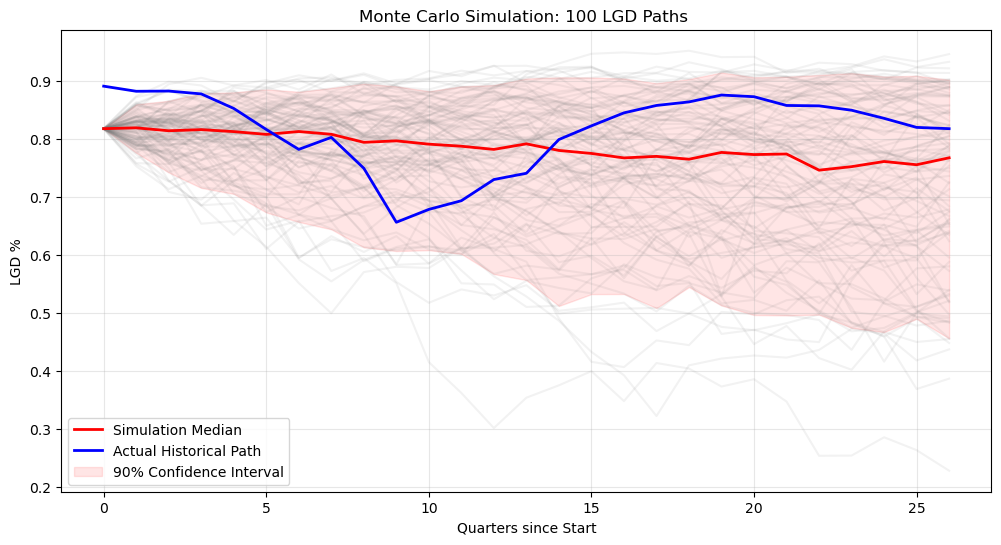

In [12]:
# randomwalk


df_hw = pd.read_csv('output/recovery.csv')
lgd_raw = df_hw['Retail_LGD_pc'].values

# 2. Transform to Logit Space to keep values between 0 and 1
def logit(p):
    p = np.clip(p, 0.001, 0.999)
    return np.log(p / (1 - p))

def inv_logit(p):
    return 1 / (1 + np.exp(-p))

logit_lgd = logit(lgd_raw)

# 3. Calculate "Step" characteristics (Drift and Volatility)
diffs = np.diff(logit_lgd)
mu = np.mean(diffs)   # Average trend
sigma = np.std(diffs) # Historical "jumpiness"
# 4. Monte Carlo Settings
np.random.seed(101)
n_paths = 100          # Number of simulated lines
n_steps = len(lgd_raw) # Number of quarters to simulate
start_val = logit_lgd[-1] # Start from the FIRST point in history

# 5. Run Simulation
paths = np.zeros((n_steps, n_paths))
paths[0, :] = start_val

for t in range(1, n_steps):
    # Random Walk: Next = Prev + Drift + (Random * Volatility)
    random_shocks = np.random.normal(0, sigma, n_paths)
    paths[t, :] = paths[t-1, :] + mu + random_shocks

# Convert all paths back to percentages
sim_lgd_pct = inv_logit(paths)

# 6. Visualization
plt.figure(figsize=(12, 6))

# Plot all 100 paths in light grey
plt.plot(sim_lgd_pct, color='grey', alpha=0.1)

# Plot the Median Path and the Actual Historical Path for comparison
plt.plot(np.median(sim_lgd_pct, axis=1), color='red', linewidth=2, label='Simulation Median')
plt.plot(lgd_raw, color='blue', linewidth=2, label='Actual Historical Path')

# Shade the 5th to 95th percentile (The "Risk Envelope")
upper = np.percentile(sim_lgd_pct, 95, axis=1)
lower = np.percentile(sim_lgd_pct, 5, axis=1)
plt.fill_between(range(n_steps), lower, upper, color='red', alpha=0.1, label='90% Confidence Interval')

plt.title(f"Monte Carlo Simulation: 100 LGD Paths ")
plt.ylabel("LGD %")
plt.xlabel("Quarters since Start")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.show()